## Step 1: Create a folder to keep all of the reduced files in

In [1]:
%cd 2023nov12-redux
%pwd

/home/carolinevr/lris-data-redux-2026/2023nov12-redux


'/home/carolinevr/lris-data-redux-2026/2023nov12-redux'

# Step 2: Incorporate slitmask information using `TILSOTUA`

In [31]:
from tilsotua import xytowcs

maskdir = '/home/carolinevr/lris-data-redux-2026/cecilia3-with-tilsotua-info/'
file3 = maskdir+'cecilia3.file3'
file1 = maskdir+'cecilia3.'
outputfile = maskdir+'cecilia3_tilsotua_output'

# converts x,y to astropy World Coordinate System (WCS)
# xytowcs(data_input_name=file3, output_file=outputfile)
        #obj_file='cecilia3/cecilia3.autoslitin.trim', file1='cecilia3/cecilia3.')

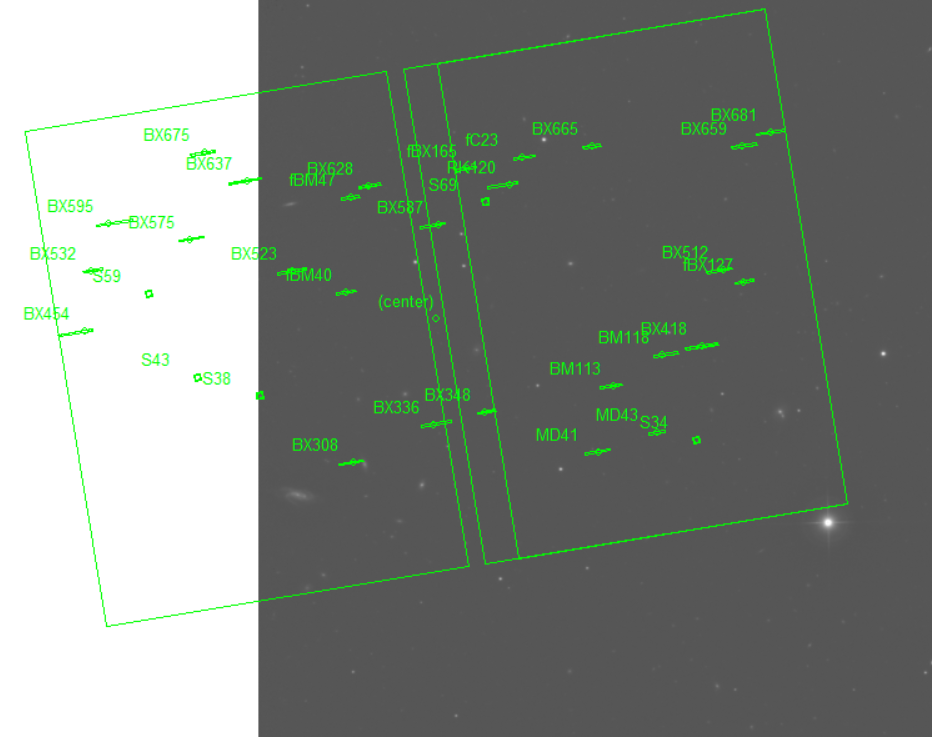

# Step 3: Run pypeit_setup to organize the raw files by datasets

In [5]:
! pypeit_setup -s keck_lris_red_mark4 -r ../2023nov12_with_tilsotua_info/red

    [INFO] - pypeitsetup.py:from_file_root:197 - Found 41 keck_lris_red_mark4 raw files.
    [INFO] - metadata.py:_build:206 - Building metadata for 41 files.
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00001.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00009.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00010.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00011.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00012.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00013.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00014.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00015.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00016.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00017.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00018

## Step 3.1 Append slitmask information to the trace files in the raw data

In [ ]:
# with open ("/home/carolinevr/lris-data-redux-2026/2023nov12-redux/setup_files/keck_lris_red_mark4.calib") as f:
#     lines = [line.strip() for line in f.readlines() if line.strip()]

# setup_letter = 'B'

# for line in lines:
#     if line==(setup_letter+":"):
#         print(line)


### get every trace file in the setup ###
tracefiles =['/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00012.fits',
       '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00013.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00014.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00022.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00023.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00024.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00025.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00026.fits',
      '/home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00027.fits']

In [28]:
print(outputfile)

/home/carolinevr/cecilia3-raw-data/lris-data-redux-2026/cecilia3_tilsotua_output


In [39]:
from astropy.io import fits

for tracefile in tracefiles:
    tracehdus = fits.open(tracefile)
    tracehdus.info()
    autoslithdus = fits.open(outputfile+".fits")
    autoslithdus.info()

    for hdu in autoslithdus[1:]:
        tracehdus.append(hdu)
    tracehdus.info()
    tracehdus.writeto(tracefile+"_with_maskinfo.fits", overwrite=True)

Filename: /home/carolinevr/lris-data-redux-2026/2023nov12-redux/../2023nov12_with_tilsotua_info/red/r231112_00012.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     347   (4234, 2124)   int16 (rescales to uint16)   
  1  Exposure Events    1 TableHDU        17   3R x 2C   [A26, A80]   
Filename: /home/carolinevr/lris-data-redux-2026/cecilia3-with-tilsotua-info/cecilia3_tilsotua_output.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  ObjectCat     1 BinTableHDU     50   32R x 19C   [6A, K, D, D, 1A, D, D, D, 1A, D, D, D, D, D, D, D, D, 14A, K]   
  2  MaskDesign    1 BinTableHDU     47   1R x 19C   [J, 68A, J, 68A, 19A, J, J, 68A, 68A, 68A, D, D, 8A, E, D, 23A, E, I, 19A]   
  3  DesiSlits     1 BinTableHDU     30   32R x 10C   [K, J, D, D, 1A, E, E, E, E, 20A]   
  4  SlitObjMap    1 BinTableHDU     22   32R x 5C   [K, K, K, D, D]   
  5  MaskBlu       1 BinTabl

## Step 3.2 Decide what setup to reduce and create a .pypeit file

In [40]:
! pypeit_setup -s keck_lris_red_mark4 -r ../2023nov12_with_tilsotua_info/red -c B

    [INFO] - pypeitsetup.py:from_file_root:197 - Found 50 keck_lris_red_mark4 raw files.
    [INFO] - metadata.py:_build:206 - Building metadata for 50 files.
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00001.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00009.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00010.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00011.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00012.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00012.fits_with_maskinfo.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00013.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00013.fits_with_maskinfo.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00014.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00014.fits_with_maskinfo.fits
    [INFO] - m

## Step 3.3: Inspect the `.pypeit` file to make sure the file types were accurately assigned

cross-check with logs. make sure you're noting red or blue frame numbers correctly

    what to look for: 
        including MIRA when you don't want to on Blue
        including frames with counts that are too high for standard stars


## Step 3.4: Make edits to the Parameter block in the `.pypeit` file if necessary

# Step 4: Run the main `run_pypeit` call

In [2]:
%pwd
%cd keck_lris_red_mark4_B
%pwd

/home/carolinevr/lris-data-redux-2026/2023nov12-redux/keck_lris_red_mark4_B


'/home/carolinevr/lris-data-redux-2026/2023nov12-redux/keck_lris_red_mark4_B'

In [ ]:
! run_pypeit keck_lris_red_mark4_B.pypeit -o

    [INFO] - inputfiles.py:from_file:136 - Loading the reduction file
    [INFO] - inputfiles.py:from_file:214 - PypeIt input file loaded successfully.
    [INFO] - inputfiles.py:vet:685 - PypeIt file successfully vetted.
    [INFO] - pypeit.py:__init__:82 - Loaded spectrograph keck_lris_red_mark4
    [INFO] - pypeit.py:__init__:83 - Setting configuration-specific parameters using r231112_00028.fits.
 [WARNING] - parset.py:to_config:662 - Selected configuration file already exists and will be overwritten!
    [INFO] - pypeit.py:__init__:99 - Compiling metadata
    [INFO] - metadata.py:_build:206 - Building metadata for 29 files.
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00009.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00010.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00011.fits
    [INFO] - metadata.py:_build:235 - Adding metadata for r231112_00019.fits
    [INFO] - metadata.py:_build:235 - Adding metadata f